# Potential density pairs using tree-code

In [1]:
import numpy as np

filename = "C:/Users/user/Downloads/Dynamics3/sphere_10k.in"

def generate_treecode_ic(filename, N=10000, R_max=1.0):
    
    # total mass 1
    masses = np.ones(N) / N
    
    # positions
    phi = np.random.uniform(0, 2 * np.pi, N)
    costheta = np.random.uniform(-1, 1, N)
    u = np.random.uniform(0, 1, N)
    
    theta = np.arccos(costheta)
    r = R_max * u**(1/3)
    
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    
    # velocities
    vx = np.zeros(N)
    vy = np.zeros(N)
    vz = np.zeros(N)
    
    # writing in the exact format of the Tree-code
    with open(filename, 'w') as f:
        f.write(f"{N}\n")         # Nport
        f.write("3\n")            # N of dimensions
        f.write("0.0\n")          # time
        
        # Array of masses
        for m in masses:
            f.write(f"{m:.8e}\n")
            
        # Array of positions
        for i in range(N):
            f.write(f"{x[i]:.8e} {y[i]:.8e} {z[i]:.8e}\n")
            
        # Array of velocities
        for i in range(N):
            f.write(f"{vx[i]:.8e} {vy[i]:.8e} {vz[i]:.8e}\n")

# Generate a sphere of 10,000 particles
generate_treecode_ic(filename, N=10000)

```bash
treecode.exe in="C:/Users/user/Downloads/Dynamics3/sphere_10k.in" out=sphere_10k.out dtime=0.01 eps=0.05 theta=0.7 tstop=3.0 dtout=0.05 > log.txt
```

First maximum at t = 1.1500, 2K/|W| = 1.7920
Difference between collapse time and theoretical collapse time: 0.0393
error = 3.928%
Initial energy = -0.5949
Final energy = -0.5952
energy conservation = 0.00026


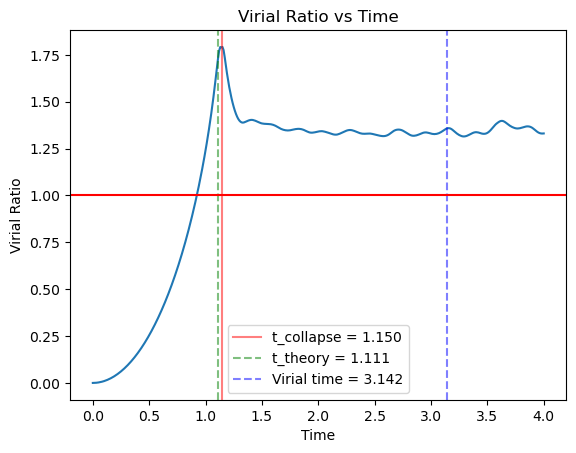

In [6]:
import matplotlib.pyplot as plt 

#plot the virial ratio
#file is organized in lines of 8 columns 
#column 0 time 
#column 2 kinetic energy
#column 3 potential energy

times = []
ke = []
pe = []

with open("C:/Users/user/Downloads/treecode/log_3.txt", "r") as f:
    for line in f:
        columns = line.split()
        if len(columns) == 8 and columns[0].replace(".", "", 1).isdigit():
            times.append(float(columns[0]))
            ke.append(float(columns[2]))
            pe.append(float(columns[3]))
            

times = np.array(times)
ke = np.array(ke)
pe = np.array(pe)
virial = np.array(2*ke/pe)
peak_idx = np.argmax(virial)

virial_ratio = 2*ke / pe

theoretical = np.pi/np.sqrt(8)

print(f"First maximum at t = {times[peak_idx]:.4f}, 2K/|W| = {virial[peak_idx]:.4f}")
print(f"Difference between collapse time and theoretical collapse time: {np.absolute(times[peak_idx]-theoretical):.4f}")
print(f"error = {np.absolute(times[peak_idx]-theoretical)*100:.4}%")
print(f"Initial energy = {ke[0]-pe[0]:.4}")
print(f"Final energy = {ke[-1]-pe[-1]:.4}")
print(f"energy conservation = {(ke[0]-pe[0]-(ke[-1]-pe[-1])):.4}")


plt.plot(times, virial_ratio)
plt.axvline(x=times[peak_idx], color='red', alpha=0.5, label=f't_collapse = {times[peak_idx]:.3f}')
plt.axvline(x=np.pi/(np.sqrt(8)), color='green', linestyle='--', alpha=0.5, label=f't_theory = {np.pi/(np.sqrt(8)):.3f}')
plt.axvline(x=np.pi, color='blue', linestyle='--', alpha=0.5, label=f'Virial time = {np.pi:.3f}')
plt.axhline(y=1, color='r', linestyle='-')
plt.xlabel("Time")
plt.ylabel("Virial Ratio")
plt.title("Virial Ratio vs Time")
plt.legend()
plt.show()


the ratio computed 
$$
\frac{2K}{U}=\frac{2(K_{bound}+K_{esc})}{\left|{U_{bound}+U_{esc}}\right|}
$$
since escaped particle are further away their contributions to the potential is almost zero, and if the bound particles are at equilibria we can rewrite the ratio as 
$$
\frac{2K}{U} \approx 1 + \frac{2K_{esc}}{\left|{U_{bound}}\right|}
$$

In [15]:
relax_times = times > np.pi 
ke_relax = ke[relax_times]
pe_relax = pe[relax_times]
 
virial_relax = (2*ke_relax)/pe_relax
mean_virial_relax = np.mean(virial_relax)

stolen_kinetic = mean_virial_relax - 1 

print(f"Stolen energy by evaporating particles = {stolen_kinetic:.4f}")
print(f"So {stolen_kinetic*100:.2f}% of the energy to keep the all system bound has escaped")

Stolen energy by evaporating particles = 0.3504
So 35.04% of the energy to keep the all system bound has escaped


In [25]:
final = virial_ratio[-1]
print(f"last value of the virial ratio = {final:.2f} we will use it to fit the dumping function")

last value of the virial ratio = 1.33 we will use it to fit the dumping function


I was thinking of fitting this with a damping armonic oscillator function but idk, maybe somenthing like 
$$
y = 1.33 + Ae^{-\gamma t}cos({\omega t - \alpha})
$$
$$
\omega = \frac{2\pi}{\pi}=2
$$
now if i start at $t=0$ the virial ratio (Q) is $0$ also and so i get that A and $\alpha$ are not indipent by each other bc
$$
0 = 1.33 + Acos(-\alpha)
$$
lets start from the maximum instead, i can define a new time $\tau = t - t_{coll}$ this is going to be the maximum of the cosine and so i can take $-\alpha = 0$
$$
y(\tau) = 1.33 + Ae^{-\gamma \tau}cos(\omega\tau - \alpha)
$$ 

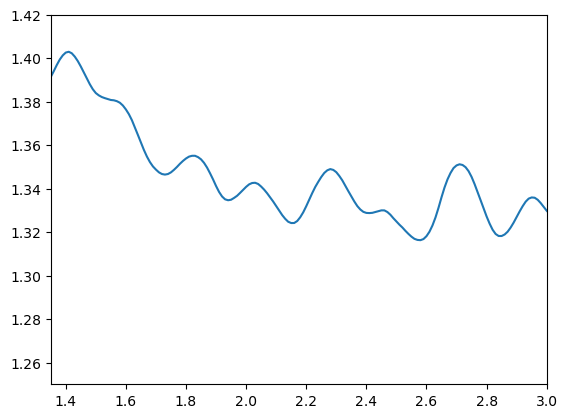

In [44]:
plt.plot(times,virial_ratio)
plt.xlim(1.35, 3)
plt.ylim(1.25,1.42)
plt.show()

In [57]:
A_guess = virial[peak_idx] - virial_ratio[-1]

second_time = (times > 1.37) & (times < 3)
times_slice = times[second_time]
second_virial_ratio = virial_ratio[second_time]
idx_max = np.argmax(second_virial_ratio)
t_2 = times_slice[idx_max]

second_maximum = np.max(second_virial_ratio)
second_maximum_position = [np.argmax(second_time)]


print(f"position of the second maximum in the sliced array {idx_max}")
print(f"This is the initial guess that we are going to use for A = {A_guess:.2f}")
print(f"This is the second max of the virial ratio = {second_maximum:.2f} which occure at time t = {t_2:.2f}")

position of the second maximum in the sliced array 3
This is the initial guess that we are going to use for A = 0.46
This is the second max of the virial ratio = 1.40 which occure at time t = 1.41


In [58]:
period = np.abs(times[peak_idx] - t_2 )
omega_guess = (2*np.pi) / period

print(f"Initial guess for the angular frequency {omega_guess:.2f}")

Initial guess for the angular frequency 24.17


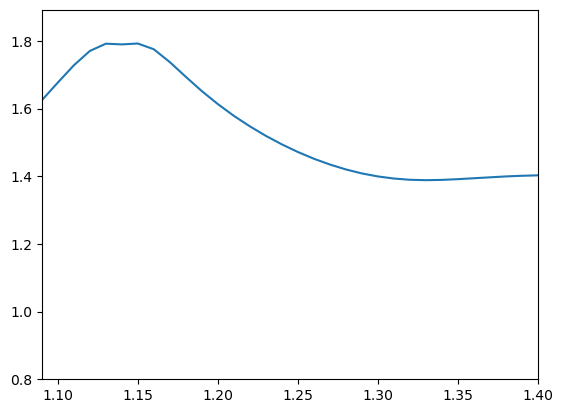

In [75]:
plt.plot(times, virial_ratio)
plt.xlim(1.09, 1.4)
plt.ylim(0.8, (virial_ratio[peak_idx]+0.1))
plt.show()

In [74]:
third_time = (times > 1.09) & (times < 1.4)
times_slice = times[third_time]
third_virial_ratio = virial_ratio[third_time]
idx_min = np.argmin(third_virial_ratio)
t_min = times_slice[idx_min]

first_minimum = np.min(third_virial_ratio)
first_minimum_position = [np.argmin(t_min)]


print(f"position of the first minimum in the sliced array {idx_min}")
print(f"This is the first minimum of the virial ratio = {first_minimum:.2f} which occure at time t = {t_min:.2f}")

position of the first minimum in the sliced array 23
This is the first minimum of the virial ratio = 1.39 which occure at time t = 1.33


In [78]:
new_period = 2 * (t_min - times[peak_idx])
new_omega = (2*np.pi) / new_period

mean_period = (new_period+period)/2
mean_omega = (new_omega+omega_guess)/2

print(f"So my guess for period and omega are : {mean_period:.2f} , {mean_omega:.2f}")



So my guess for period and omega are : 0.31 , 20.81


So the amplitude from the 2 max goes from: 0.48 to 0.05 (1.38-1.33)

In [81]:
A_1 = virial[peak_idx] - virial[-1]
A_2 = second_maximum - virial[-1]

gamma_guess = (-np.log(A_2/A_1))/(t_2-times[peak_idx])

print(f"My initial guess for the dump coefficient {gamma_guess:.2f}")

My initial guess for the dump coefficient 7.13


fit results:
A = 0.2848
Gamma = 8.0000
Omega = 12.0000
Offset = 1.3459
A = 0.4614144315150086, gamma = 2.0, omega = 14.3, offset = 1.3306155039980208, phi = 0.0


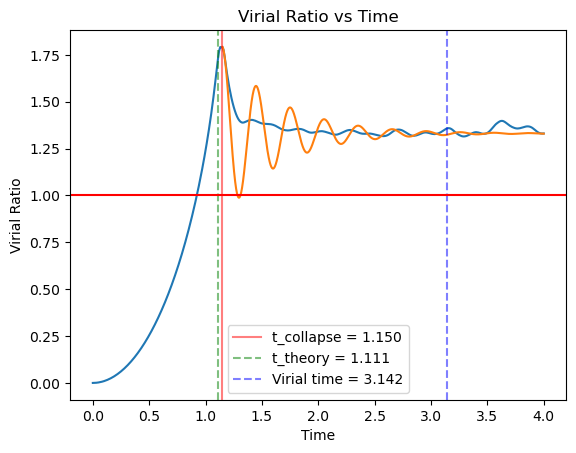

In [108]:
#now we are ready to try fit this 
from scipy.optimize import curve_fit

offset = final

def damped_model(t, A, gamma, omega, offset, phi):
    t_coll = times[peak_idx]
    return offset + A * np.exp(-gamma * (t - t_coll)) * np.cos(omega * (t - t_coll) + phi)

t_slice = (times >= 1.25) & (times <= 4.0)


t_fit = times[t_slice]
Q_fit = virial[t_slice]

p0 = [A_1 , gamma_guess, mean_omega, offset, 0.0]


low  = [0.01, 0.01, 12.0, 1.30, -np.pi]
high = [0.50, 8.00, 22.0, 1.40,  np.pi]

popt, pcov = curve_fit(damped_model, t_fit, Q_fit, p0=p0, bounds=(low, high))

A_opt, gamma_opt, omega_opt, offset_opt, phi_opt = popt

print(f"fit results:")
print(f"A = {A_opt:.4f}")
print(f"Gamma = {gamma_opt:.4f}")
print(f"Omega = {omega_opt:.4f}")
print(f"Offset = {offset_opt:.4f}")
print(f"A = {A_1}, gamma = {gamma_guess}, omega = {omega_guess}, offset = {offset}, phi = {0.0}")

t_x = np.linspace(times[peak_idx],4,10000)
t_plot = np.linspace(times[peak_idx], 4.0, 1000)
f_opt = damped_model(t_plot, *popt)

f = damped_model(t_x, A_1, gamma_guess, mean_omega, offset, 0.0)







plt.plot(times,virial)
plt.plot(t_x, f)
plt.axvline(x=times[peak_idx], color='red', alpha=0.5, label=f't_collapse = {times[peak_idx]:.3f}')
plt.axvline(x=np.pi/(np.sqrt(8)), color='green', linestyle='--', alpha=0.5, label=f't_theory = {np.pi/(np.sqrt(8)):.3f}')
plt.axvline(x=np.pi, color='blue', linestyle='--', alpha=0.5, label=f'Virial time = {np.pi:.3f}')
plt.axhline(y=1, color='r', linestyle='-')
plt.xlabel("Time")
plt.ylabel("Virial Ratio")
plt.title("Virial Ratio vs Time")
plt.legend()
plt.show()

#plt.figure(figsize=(10,6))
#plt.plot(times, virial, label='data', color='black', alpha=0.3)
#plt.plot(t_fit, damped_model(t_fit, *popt), 'r--', label='Damped model', linewidth=2)
#plt.axhline(offset_opt, color='blue', linestyle=':', label='Fit')
#plt.title("fit on virial rate")
#plt.xlabel("Time")
#plt.ylabel("Q")
#plt.legend()
#plt.show()




Min <r> at t = 1.1500


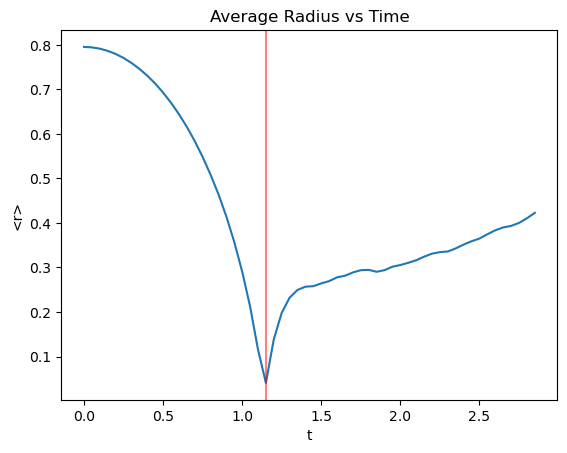

In [24]:
times = []
avg_r = []

with open("C:/Users/user/Downloads/treecode/sphere_10k_2.out", "r") as f:
    while True:
        first_line = f.readline()
        if not first_line:
            break
            
        n_particles = int(first_line.strip())
        
        ndim = float(f.readline().strip())
        
        current_time = float(f.readline().strip())
        
        for _ in range(n_particles):
            f.readline()
            
        coords = np.zeros((n_particles, 3))
        for j in range(n_particles):
            coords[j] = [float(x) for x in f.readline().split()]
            
        for _ in range(n_particles):
            f.readline()
            
        com = np.mean(coords, axis=0)
        
        r = np.linalg.norm(coords - com, axis=1)
        
        avg_r.append(np.median(r))
        times.append(current_time)

times = np.array(times)
avg_r = np.array(avg_r)

min_idx = np.argmin(avg_r)
min_time = times[min_idx]

print(f"Min <r> at t = {min_time:.4f}")

plt.plot(times, avg_r)
plt.axvline(x=min_time, color='red', alpha=0.5)
plt.xlabel('t')
plt.ylabel('<r>')
plt.title("Average Radius vs Time")
plt.show()
